# BigQuery 인프라 검증

다이소 뷰티 분석 프로젝트의 **BigQuery 데이터 웨어하우스 인프라**를 검증합니다.

| 항목 | 내용 |
|------|------|
| 데이터셋 | `daiso` |
| 스키마 버전 | ERD v3 (18개 테이블) |
| 적재 방식 | UPSERT (MERGE 패턴) |
| 활용 | Tableau 대시보드 + 시뮬레이터 VIEW |

In [1]:
import os
import warnings
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from google.cloud import bigquery
from google.oauth2 import service_account

mpl.rcParams["font.family"] = "Malgun Gothic"
mpl.rcParams["axes.unicode_minus"] = False
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path(r"G:/Final_proj/Total_clear/데이터")
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT

SERVICE_KEY_NAME = "daiso-analysis-4d05c813a295.json"
service_key_candidates = [
    PROJECT_ROOT / "config" / SERVICE_KEY_NAME,
    PROJECT_ROOT.parent / "config" / SERVICE_KEY_NAME,
]
env_key = os.environ.get("GOOGLE_APPLICATION_CREDENTIALS")
if env_key:
    service_key_candidates.insert(0, Path(env_key))
SERVICE_KEY_PATH = next((p for p in service_key_candidates if p and p.exists()), None)


def get_client():
    if SERVICE_KEY_PATH:
        credentials = service_account.Credentials.from_service_account_file(str(SERVICE_KEY_PATH))
        return bigquery.Client(credentials=credentials, project=credentials.project_id)
    return bigquery.Client()


def query_to_df(sql: str) -> pd.DataFrame:
    return get_client().query(sql).to_dataframe()


def list_tables(dataset: str = "daiso") -> list:
    client = get_client()
    tables = client.list_tables(f"{client.project}.{dataset}")
    return [t.table_id for t in tables]


print(f"프로젝트 루트: {PROJECT_ROOT}")
if SERVICE_KEY_PATH:
    print(f"BigQuery 키 파일: {SERVICE_KEY_PATH}")
else:
    print("BigQuery 키 파일을 찾지 못했습니다. 기본 인증(ADC)으로 연결을 시도합니다.")


BigQuery 연결 완료


## 1. 테이블 목록 및 행 수

In [2]:
# 전체 테이블 목록 조회
tables = list_tables()
print(f'전체 테이블 수: {len(tables)}개\n')

# 테이블별 행 수 조회
df_tables = query_to_df("""
SELECT
    table_id,
    row_count,
    ROUND(size_bytes / 1024 / 1024, 2) AS size_mb
FROM `daiso.__TABLES__`
ORDER BY row_count DESC
""")

print(f"{'테이블':<30} {'행 수':>12} {'크기(MB)':>10}")
print('-' * 55)
for _, row in df_tables.iterrows():
    print(f"{row['table_id']:<30} {row['row_count']:>12,} {row['size_mb']:>10.2f}")

print(f"\n총 행 수: {df_tables['row_count'].sum():,}")
print(f"총 크기: {df_tables['size_mb'].sum():.1f} MB")

전체 테이블 수: 52개

테이블                                     행 수     크기(MB)
-------------------------------------------------------
review_aspects                      479,616      18.54
reviews_core                        393,239      18.57
reviews_text                        393,239      40.38
review_absa                         393,229      20.83
products_ingredients                 27,975       0.43
user_id_map                          26,800       0.45
users_profile                        26,800       1.17
users_repurchase                     14,806       0.45
search_trends                        11,920       0.82
v_brand_dashboard_master              6,830       2.17
v_pivot                               5,694       0.17
ingredients_dic                       1,741       0.09
products_category                       950       0.04
products_core                           950       0.09
products_stats                          950       0.06
sli_results                             949      

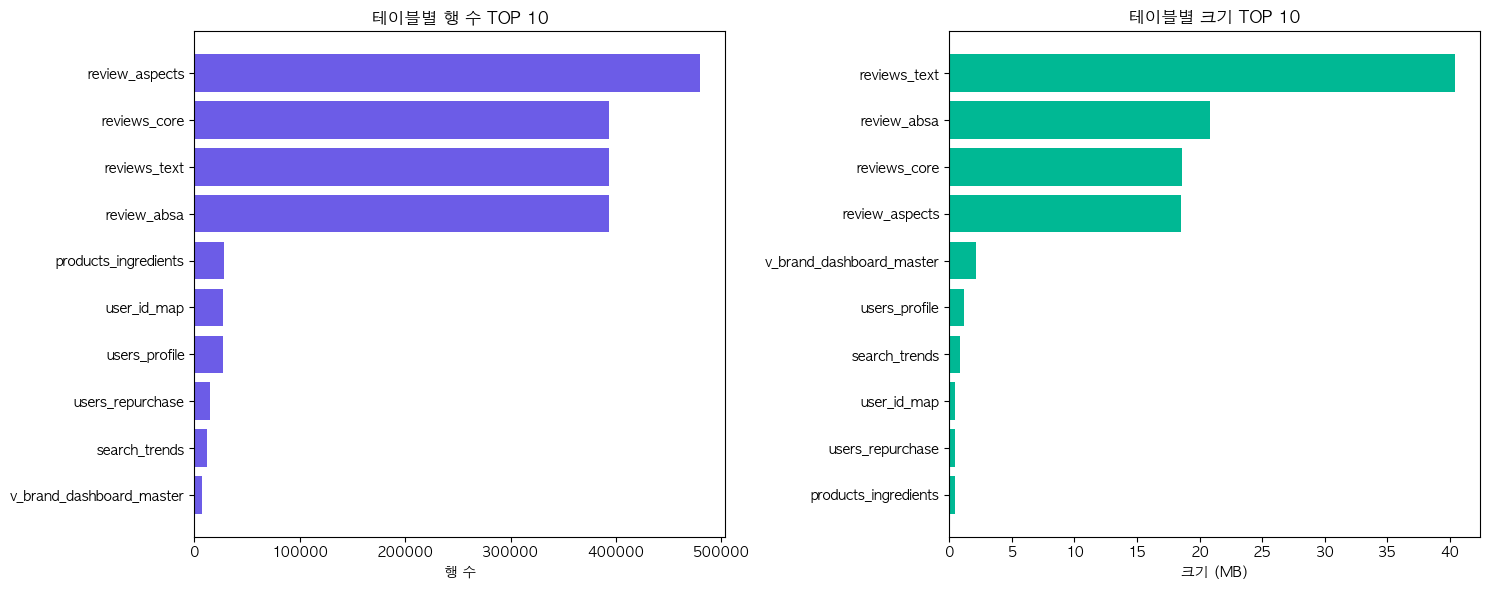

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 행 수 기준
top10 = df_tables.nlargest(10, 'row_count')
axes[0].barh(top10['table_id'][::-1], top10['row_count'][::-1], color='#6C5CE7')
axes[0].set_xlabel('행 수')
axes[0].set_title('테이블별 행 수 TOP 10', fontweight='bold')

# 크기 기준
top10_size = df_tables.nlargest(10, 'size_mb')
axes[1].barh(top10_size['table_id'][::-1], top10_size['size_mb'][::-1], color='#00B894')
axes[1].set_xlabel('크기 (MB)')
axes[1].set_title('테이블별 크기 TOP 10', fontweight='bold')

plt.tight_layout()
plt.show()

## 2. ERD 관계 검증 (JOIN 무결성)

In [4]:
# FK 관계 무결성 검증
df_fk = query_to_df("""
SELECT
    'products_core → brands' AS relation,
    COUNT(*) AS total_rows,
    COUNTIF(b.brand_id IS NOT NULL) AS matched,
    COUNTIF(b.brand_id IS NULL) AS orphaned
FROM daiso.products_core p
LEFT JOIN daiso.brands b ON p.brand_id = b.brand_id

UNION ALL

SELECT
    'reviews_core → products_core',
    COUNT(*),
    COUNTIF(p.product_code IS NOT NULL),
    COUNTIF(p.product_code IS NULL)
FROM daiso.reviews_core r
LEFT JOIN daiso.products_core p ON r.product_code = p.product_code

UNION ALL

SELECT
    'review_absa → reviews_core',
    COUNT(*),
    COUNTIF(r.review_id IS NOT NULL),
    COUNTIF(r.review_id IS NULL)
FROM daiso.review_absa a
LEFT JOIN daiso.reviews_core r ON a.review_id = r.review_id

UNION ALL

SELECT
    'sli_results → products_core',
    COUNT(*),
    COUNTIF(p.product_code IS NOT NULL),
    COUNTIF(p.product_code IS NULL)
FROM daiso.sli_results s
LEFT JOIN daiso.products_core p ON s.product_code = p.product_code
""")

df_fk['match_rate'] = (df_fk['matched'] / df_fk['total_rows'] * 100).round(1)
print('FK 관계 무결성 검증:')
df_fk

FK 관계 무결성 검증:


,relation,total_rows,matched,orphaned,match_rate
0,products_core → brands,950,950,0,100.0
1,reviews_core → products_core,393239,360668,32571,91.7
2,review_absa → reviews_core,393229,393229,0,100.0
3,sli_results → products_core,949,908,41,95.7


## 3. 핵심 파생변수 검증

In [5]:
# engagement_score, cp_index 분포 확인
df_derived = query_to_df("""
SELECT
    ps.product_code,
    ps.engagement_score,
    ps.cp_index,
    ps.review_density,
    ps.risk_score,
    ps.review_count,
    p.price
FROM daiso.products_stats ps
JOIN daiso.products_core p ON ps.product_code = p.product_code
WHERE ps.engagement_score IS NOT NULL
""")

print('파생변수 기초 통계:')
df_derived[['engagement_score', 'cp_index', 'review_density', 'risk_score']].describe().round(2)

파생변수 기초 통계:


,engagement_score,cp_index,review_density,risk_score
count,950.00,950.00,950.00,950.0
mean,388.80,118.38,0.79,0.0
std,424.41,185.17,1.07,0.0
min,0.00,0.00,0.00,0.0
25%,109.68,30.86,0.25,0.0
50%,221.25,62.71,0.47,0.0
75%,502.85,139.01,1.00,0.0
max,1986.50,3226.60,11.37,0.0


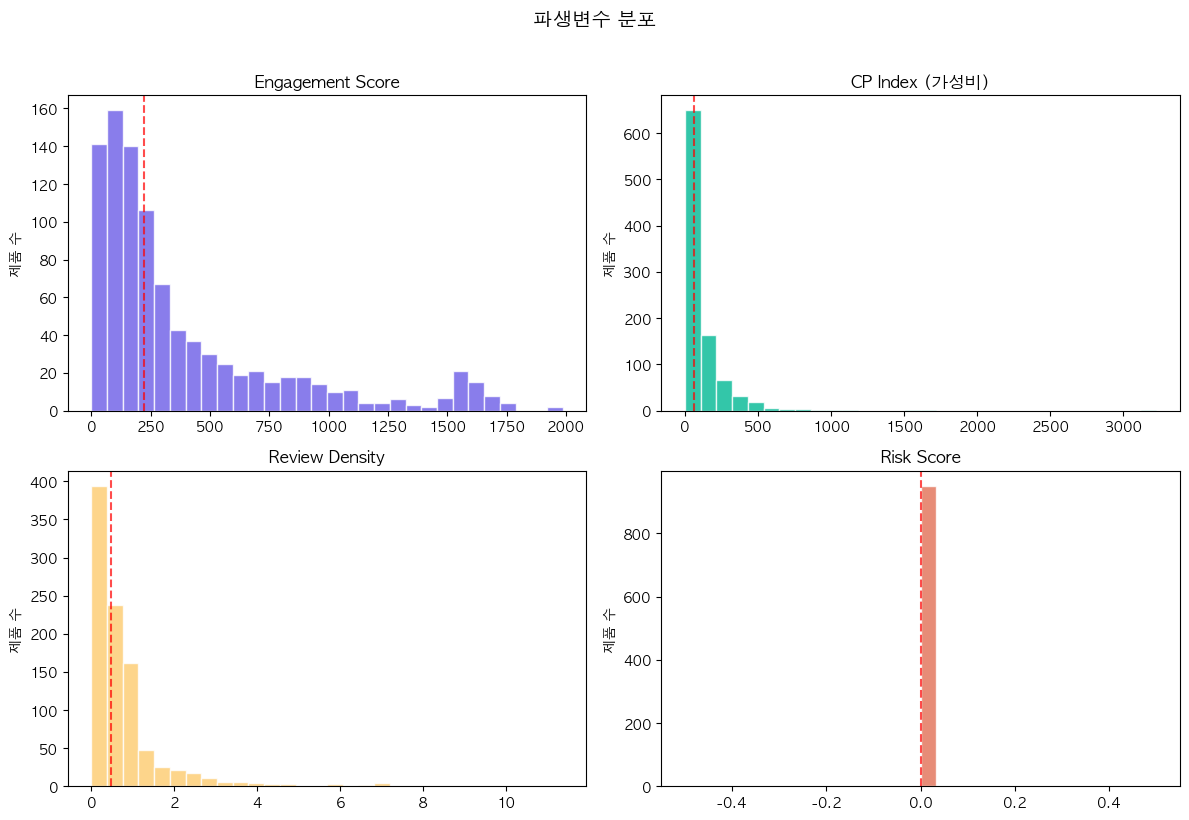

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col, color, title in zip(
    axes.flat,
    ['engagement_score', 'cp_index', 'review_density', 'risk_score'],
    ['#6C5CE7', '#00B894', '#FDCB6E', '#E17055'],
    ['Engagement Score', 'CP Index (가성비)', 'Review Density', 'Risk Score']
):
    data = df_derived[col].dropna()
    ax.hist(data, bins=30, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(data.median(), color='red', linestyle='--', alpha=0.7)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('제품 수')

plt.suptitle('파생변수 분포', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. SLI 연착륙 판별 결과 현황

In [7]:
df_sli = query_to_df("""
SELECT
    final_soft_landing,
    COUNT(*) AS product_count,
    ROUND(AVG(confidence), 3) AS avg_confidence,
    COUNTIF(is_soft_landing_dtw) AS dtw_yes,
    COUNTIF(is_soft_landing_surv) AS surv_yes,
    COUNTIF(is_soft_landing_rule) AS rule_yes,
    COUNTIF(is_soft_landing_ml) AS ml_yes
FROM daiso.sli_results
GROUP BY final_soft_landing
""")

print('SLI 연착륙 판별 결과:')
df_sli

SLI 연착륙 판별 결과:


,final_soft_landing,product_count,avg_confidence,dtw_yes,surv_yes,rule_yes,ml_yes
0,False,876,0.314,181,296,332,292
1,True,73,1.000,73,73,73,73


## 5. Tableau 대시보드 VIEW 시연

In [8]:
# 통합 스코어카드 쿼리 (Tableau VIEW 로직 재현)
df_scorecard = query_to_df("""
SELECT
    b.name AS brand,
    pc.category_1,
    p.name AS product_name,
    p.price,
    ps.engagement_score,
    ps.cp_index,
    ps.review_count,
    s.final_soft_landing,
    s.confidence AS sli_confidence
FROM daiso.products_core p
JOIN daiso.brands b ON p.brand_id = b.brand_id
JOIN daiso.products_category pc ON p.product_code = pc.product_code
JOIN daiso.products_stats ps ON p.product_code = ps.product_code
LEFT JOIN daiso.sli_results s ON p.product_code = s.product_code
ORDER BY ps.engagement_score DESC
LIMIT 20
""")

print('Engagement Score TOP 20 제품:')
df_scorecard[['brand', 'product_name', 'price', 'engagement_score',
              'cp_index', 'review_count', 'final_soft_landing']]

Engagement Score TOP 20 제품:


,brand,product_name,price,engagement_score,cp_index,review_count,final_soft_landing
0,본셉,본셉 비타씨 동결 건조 더블샷 앰플 키트,5000.0,1986.50,397.3000,287,False
1,마데카21,마데카21 테카 솔루션 수딩 미스트 토너 200 ml,5000.0,1954.40,390.8800,341,False
2,더랩 바이 블랑두,더랩 바이 블랑두 클리어 히알 물광 크림 50 ml,5000.0,1773.90,354.7800,207,False
3,파티온,파티온 노스카나인 퍼스트스텝 흔적앰플 30 ml,5000.0,1770.70,354.1400,205,False
4,더랩 바이 블랑두,더랩 바이 블랑두 클리어 히알 물광 부스터 앰플 30 ml,5000.0,1761.80,352.3600,245,False
5,본셉,본셉 레티놀 2500 IU 링클샷 퍼펙터 15 ml,5000.0,1736.85,347.3700,204,True
6,바이 리얼베리어,바이 리얼베리어 세라베이스 카밍 모이스처라이징 크림 50 ml,5000.0,1707.30,341.4600,207,False
7,VT,VT PDRN 광채토너 200 ml,5000.0,1704.80,340.9600,215,False
8,더랩 바이 블랑두,더랩바이블랑두 클리어히알결광 스킨핏프렙 40 ml,5000.0,1698.45,339.6900,174,False
9,셀더마데일리,셀더마데일리 트랜스포밍 아줄렌카밍 마스크 28 g,2000.0,1688.45,844.2250,128,False


## 6. 파이프라인 실행 이력

In [9]:
df_log = query_to_df("""
SELECT
    run_date,
    step_name,
    status,
    rows_affected,
    ROUND(duration_sec, 1) AS duration_sec
FROM daiso.pipeline_log
ORDER BY run_date DESC
LIMIT 20
""")

if len(df_log) > 0:
    print('최근 파이프라인 실행 이력:')
    display(df_log)
else:
    print('파이프라인 실행 이력 없음')

최근 파이프라인 실행 이력:


,run_date,step_name,status,rows_affected,duration_sec
0,2026-02-27 06:26:53.096173,initial_migration,success,11920,0.0


## 요약

| 항목 | 내용 |
|------|------|
| 스키마 | ERD v3 — 18개 테이블 (기존 13 + 신규 5) |
| 적재 패턴 | UPSERT (temp table → MERGE → delete) |
| FK 의존성 | 순서 보장 적재 (brands → products → reviews → ABSA/SLI) |
| 대시보드 | Tableau 연동 VIEW 8종 (시뮬레이터 100점 스코어링) |
| 파이프라인 | ETL 자동화 + 실행 이력 로깅 |